In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def show_img(img1, img2, title1, title2):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 10))

  ax1.imshow(img1)
  ax1.set_title(title1)

  ax2.imshow(img2)
  ax2.set_title(title2)

  plt.tight_layout()
  plt.show()

## Algoritmo para redução da resolução espacial.

> **O que resolução espacial?**
É a medida do nível de detalhe que um sensor consegue registrar em uma imagem. Em outras palavras é o tamanho que a área abarcada em um pixel corresponde na realidade.

O redimensionamento de uma imagem é o ***processo de alterar as dimensões dela, aumentando ou diminuindo o tamanho***. Ou seja, envolve a alteração do número de pixels da imagem, o que vai afetar tanto o tamanho visual quanto a quantidade de dados necessária para representar ela.

Em casos que a imagem é aumentada, novos pixels são criados e em casos que ela é diminuida, alguns dos pixels são removidos. Dessa maneira, o grande desafio estar em determinar como manter a qualidade visual mesmo com essas mudanças.

Os dois tipos de redimensionamento são:

* `downsampling` = diminui o número de pixels na imagem, pode ser usado para reduzir a quantidade de dados para processamento ou armazenamento.
* `upsampling` = aumenta o número de pixels da imagem, pode ser usada para deixar as imagens mais nítidas e detalhadas.



E como lidar com essa modificação no número de pixels?
> Usando **interpolação**. Que na matemática é um método que descobre um valor desconhecido que está dentro de um intervalo de valores já conhecidos (os pixels ao redor).


Em casos que a imagem foi reduzida a interpolação estima os valores de cor e intensidade dos pixels restantes com base nos pixels vizinhos. Já nos casos de adição de pixels, a interpolação estima a cor e a intensidade dos novos pixels com base nos existentes.

ps: é importante destacar que existem diversas técnicas de interpolação no processamento de imagens.

### Redimensionando uma imagem especificando as dimensões

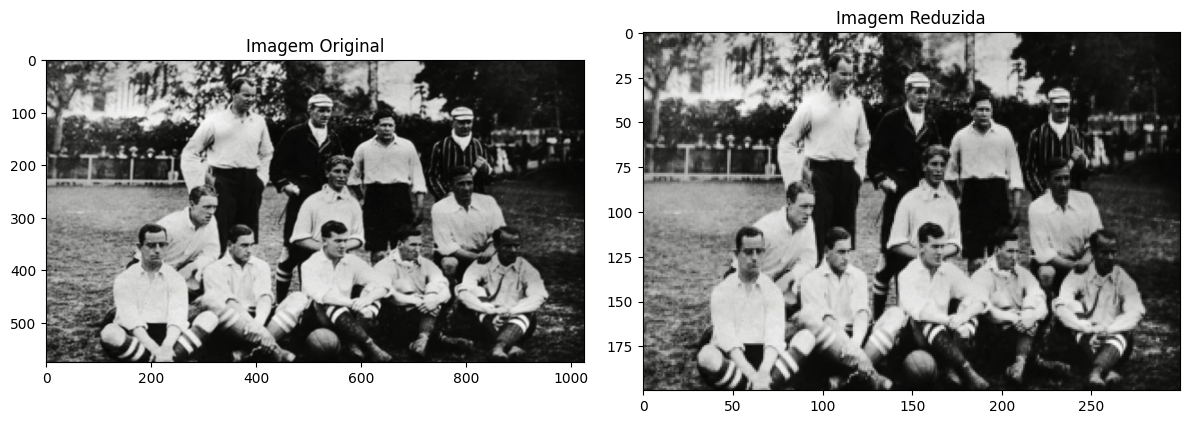

In [4]:
image = cv2.imread("/content/img/corinthians01.webp")

original_height, original_width = image.shape[:2]

new_width = 300
new_height = 200
resized_image = cv2.resize(image, (new_width, new_height))

show_img(image, resized_image, "Imagem Original", "Imagem Reduzida")

Observa-se que mesmo reduzindo a imagem ela parece menor, isso acontece porque a relação proporcional entre a largura e a altura da imagem não foram preservadas após a transformação, o que acabou distorcendo um pouco a imagem.

### Redimensionando a imagem especificando fatores de escala

Ao utilizar uma escala para redimensionar a imagem, os **valores de largura e altura** dela **são multiplicados por fatores de escala**.


Sendo o fator de escala um número que determina o quanto a imagem será diminuida ou aumentada.
* `fator de escala > 1` = amplia a imagem
* `fator de escala < 1` = reduz a imagem
* `fator de escala = 1` = mantém o tamanho da imagem

Além disso, é possível especificar diferentes fatores de escala para largura e altura.

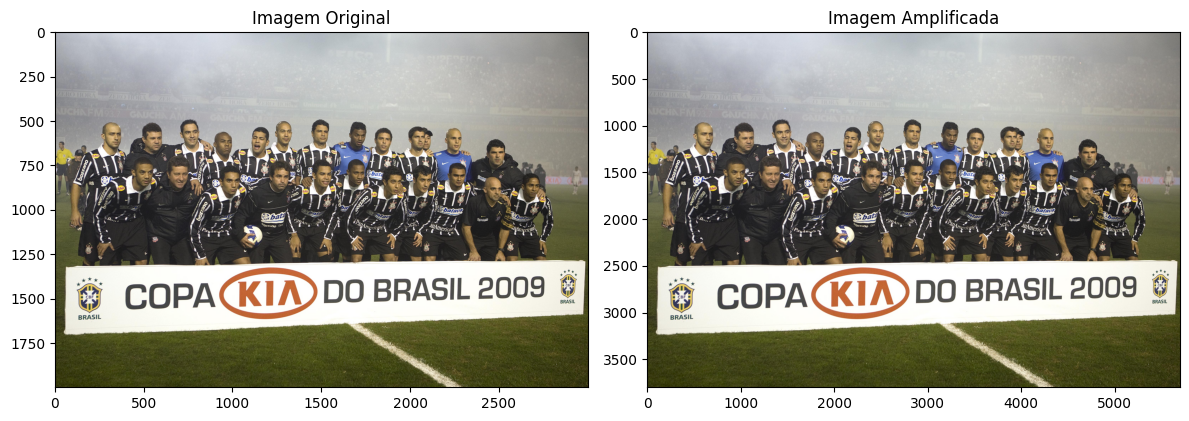

In [5]:
image2 = cv2.imread("/content/img/corinthians02.jpg")

image_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

original_size = image2.shape[:2]

scale_factor_x = 1.9
scale_factor_y = 1.9

resized_image = cv2.resize(image2, None, fx=scale_factor_x, fy=scale_factor_y)
image2_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)
resized_size = resized_image.shape[:2]

show_img(image_rgb, image2_rgb, "Imagem Original", "Imagem Amplificada")

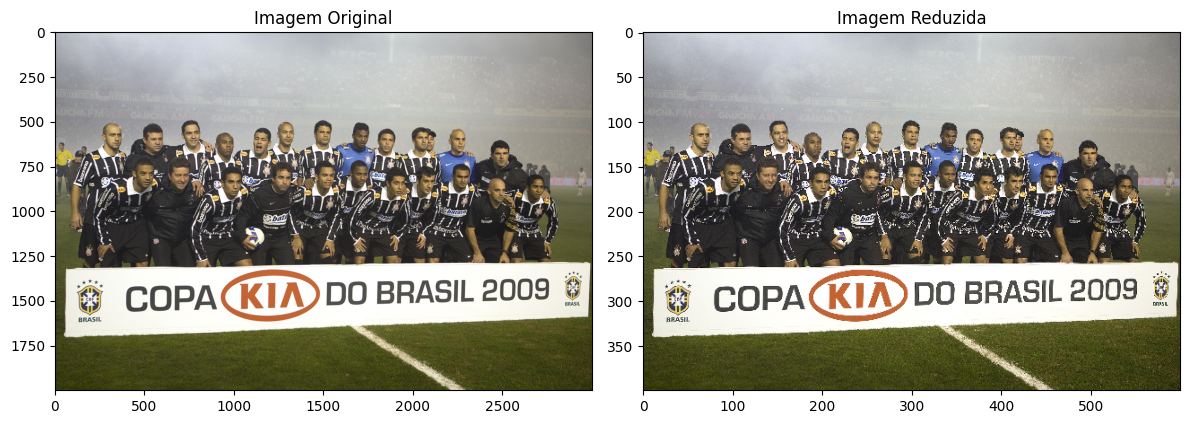

In [6]:
#reduzindo a imagem
scale_factor_x = 0.2
scale_factor_y = 0.2

resized_image = cv2.resize(image_rgb, None, fx=scale_factor_x, fy=scale_factor_y)
resized_size = resized_image.shape[:2]

show_img(image_rgb, resized_image, "Imagem Original", "Imagem Reduzida")

ps: *os fatores de escala vão manter a proporção da imagem, porém é necessário que ambos tenham o mesmo valor.*

### Métodos de interpolação para redimensionamento

Como mencionado anteriormente, a interpolação é um **método que estima e calcula novos valores de pixel ao redimensionar, rotacionar ou transformar uma imagem**.

Os principais métodos de interpolação usados são:

* interpolação do vizinho mais próximo `cv2.INTER_NEAREST`
* interpolação bilinear `cv2.INTER_LINEAR`
* interpolação bicúbica `cv2.INTER_CUBIC`
* interpolação de lanczos `cv2.INTER_LANCZOS4`
* interpolação de área `cv2.INTER_AREA`

O método padrão da função `resize` é interpolação bilinear.

### Interpolação do vizinho mais próximo

Essa técnica seleciona o valor do pixel mais próximo na imagem original e atribui ao pixel correspondente na imagem transformada.

É a forma mais simples de interpolação e é rápido, porém pode produzir resultados pixelizados e com aspecto de blocos, especial ao ampliar a imagem.

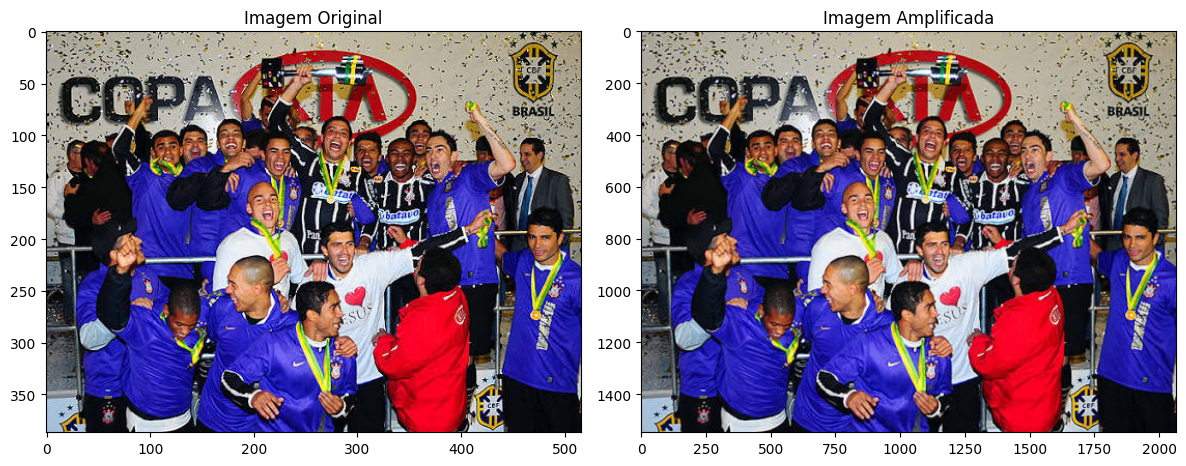

In [7]:
img = cv2.imread("/content/img/corinthians03.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


upscaled_img = cv2.resize(img, (0, 0), fx=4.0, fy=4.0, interpolation=cv2.INTER_NEAREST)

show_img(img, upscaled_img, "Imagem Original", "Imagem Amplificada")

### Interpolação bilinear

Essa técnica considera os **4 pixels mais próximos** (vizinhança 2x2) ao redor da posição calculada e d**epois realiza uma média ponderada com base na distância desses quatro pixels** ao ponto interpolado.

Dessa maneira, o resultado são ***transições mais suaves entre os pixels*** em comparação com o método do vizinho mais próximo.

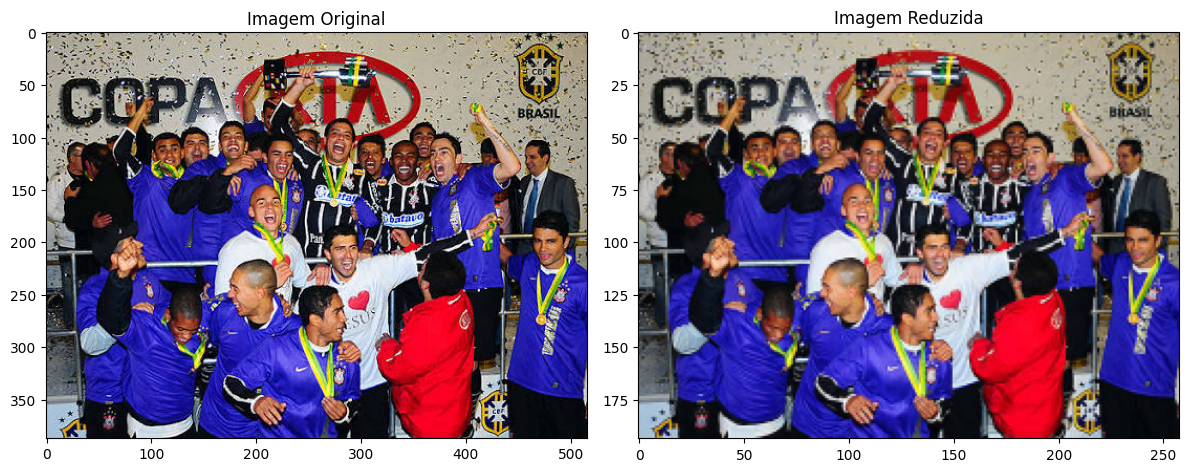

In [8]:
downscale_img = cv2.resize(img, (0, 0), fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)

show_img(img, downscale_img, "Imagem Original", "Imagem Reduzida")

### Interpolação bicúbica

É um método que **utiliza uma vizinhança de 4x4 pixels** (16 pixels) e **polinômios cúbicos para calcular o novo valor do pixel**. Ou seja, por considerar mais pixels do que a interpolação bilinear as imagens acabam ficando mais suaves, por isso é muito utilizado em ampliação de imagens.

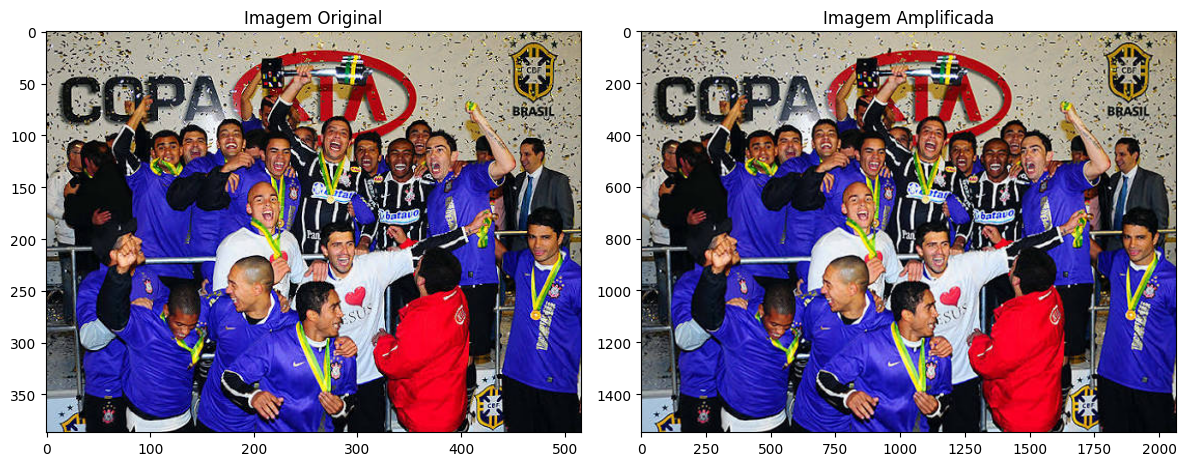

In [9]:
upscaled_img = cv2.resize(img, (0, 0), fx=4.0, fy=4.0, interpolation=cv2.INTER_CUBIC)

show_img(img, upscaled_img, "Imagem Original", "Imagem Amplificada")

### Interpolação de lanczos

Esse método usa uma **vizinhança de pixels de 8x8 e uma função sinc para calcular novos valores de pixel**. Ademais, é ***eficaz para redução de escala de imagens*** pois preserva os detalhes e minimiza artefatos de aliasing (quando a taxa de pixels está abaixo do limite necessário para registrar detalhes finos).

Porém, ela também apresenta bom desempenho em ampliações moderadas de imagem.

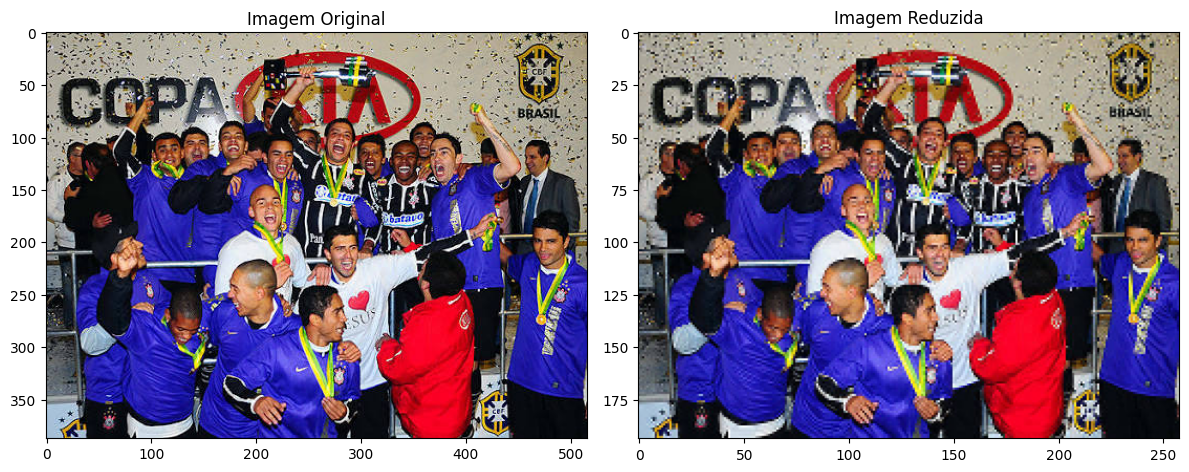

In [10]:
downscale_img = cv2.resize(img, (0, 0), fx=0.5, fy=0.5, interpolation=cv2.INTER_LANCZOS4)

show_img(img, downscale_img, "Imagem Original", "Imagem Reduzida")

### Interpolação de Área

É um método **especificamente desenvolvido para reduzir a escala de imagens**. Ele ***calcula o valor do pixel obtendo uma média ponderada dos pixels na área correspondente da imagem original***.

Ademais, é um método indicado para reduzir a escala, pois preserva os detalhes e evita serrilhamento (os pequenos "dentes" nas linhas de uma imagem) ou padrões de moiré (ondas, listras ou manchas coloridas que não existem na realidade)

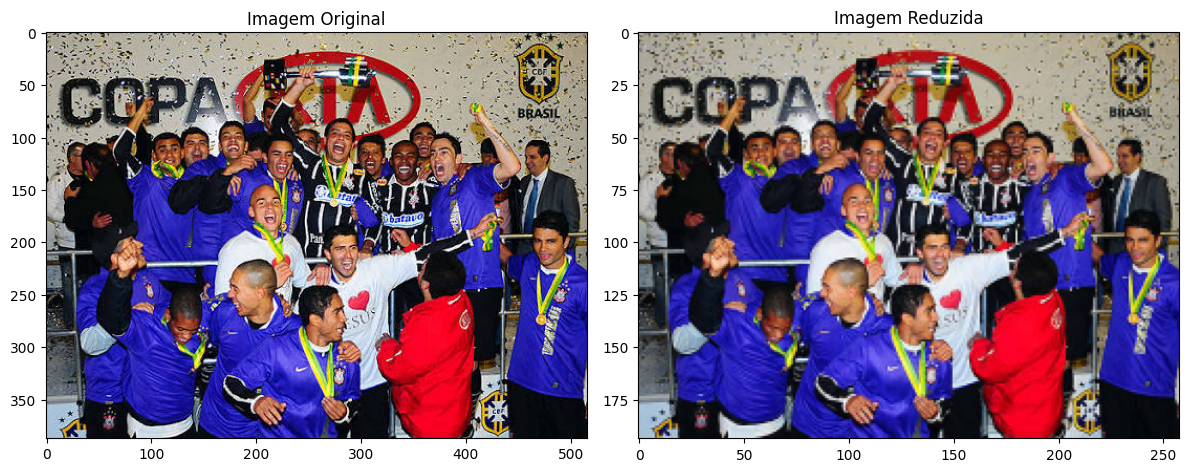

In [11]:
downscale_img = cv2.resize(img, (0, 0), fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

show_img(img, downscale_img, "Imagem Original", "Imagem Reduzida")

## Redimensionamento sem comprometer a proporção da imagem

É possível calcular novas dimensões com base na largura ou altura desejada da imagem.

Supondo que tenha uma imagem de 400x400 e a nova largura deve ser 600, é possível utilizar uma fórmula para calcular a nova altura.

In [12]:
new_width = 600
original_width = 400
original_height = 400
new_height = ((new_width / original_width) * original_height)
new_height

600.0

## Desafios no redimensionamento de imagens

* `perda de qualidade` = ao redimensionar uma imagem, ela pode perder a qualidade. por exemplo quando a imagem é reduzida e os pixels são descartados, detalhes são perdidos e por consequência a qualidade dos artefatos visuais. em relação a ampliação de imagem, como novos pixels precisam ser interpolados pode ocorrer a perda de nitidez, como desfoque ou ruído.
* `artefatos` = os métodos de interpolação, em especial o vizinho mais próximo e bilinear, podem gerar artefatos como serrilhamento (bordas irregulares) ou desfoque. por sua vez, o bicúbico e lanczos podem ajudar a diminuir esses artegas, mas exigem mais poder computacional.

## Onde o redimensionamento pode ser usado?

* Garantir a **consistência dos dados de entrada**, pois todos os dados terão dimensões consistentes, o que pode ser útil em redes neurais que esperar entradas de tamanho fixo.
* Ao utilizar imagens de tamanha consistentes o aprendizado é facilitado, acelerando tanto o treinamento quanto a inferência e ademais também reduzindo o uso de memória.

## Comparação do efeito de interpolação

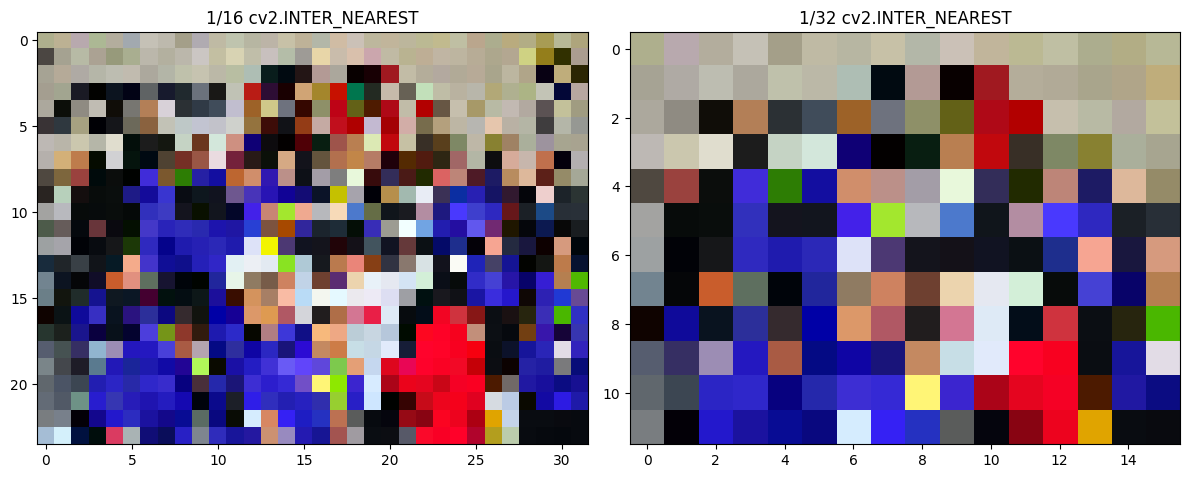

In [13]:
img_int1 = cv2.resize(img, (0, 0), fx = 0.0625, fy = 0.0625, interpolation=cv2.INTER_NEAREST)
img_int2 = cv2.resize(img, (0, 0), fx = 0.03125, fy = 0.03125, interpolation=cv2.INTER_NEAREST)

show_img(img_int1, img_int2, "1/16 cv2.INTER_NEAREST", "1/32 cv2.INTER_NEAREST")

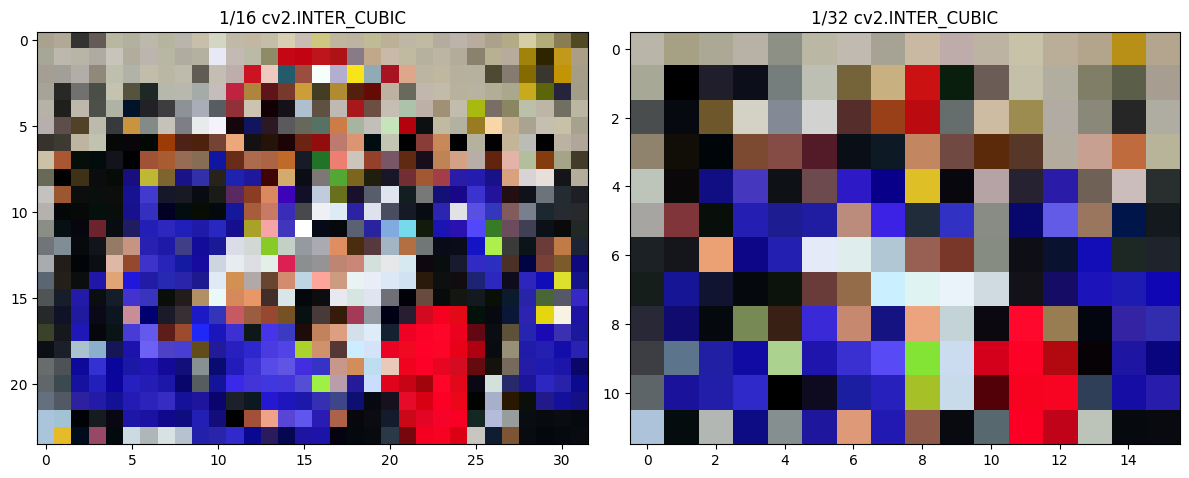

In [14]:
img_int1 = cv2.resize(img, (0, 0), fx = 0.0625, fy = 0.0625, interpolation=cv2.INTER_CUBIC)
img_int2 = cv2.resize(img, (0, 0), fx = 0.03125, fy = 0.03125, interpolation=cv2.INTER_CUBIC)

show_img(img_int1, img_int2, "1/16 cv2.INTER_CUBIC", "1/32 cv2.INTER_CUBIC")

Observa-se que as transições de cores dos pixels na interpolação cúbica são mais suaves que na interpolação vizinho próximo.

### Referências

[What is Image Resizing? A Computer Vision Guide.
](https://blog.roboflow.com/image-resizing/)